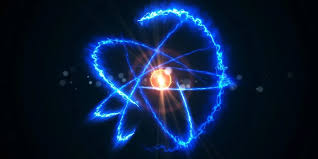

<p style="text-align: center; font-size: 28px;"><b>Particles Classification</b></p>

**Introduction**

In this lesson, we extended our understanding of Principal Component Analysis (PCA) by applying it to both dimensionality reduction and classification tasks. We explored how to calculate eigenvalues, eigenvectors, and variance ratios, and we practiced using the `scikit-learn` implementation of PCA. We also compared models trained on PCA-transformed features versus models trained on the original data to evaluate the trade-offs between dimensionality reduction and model performance.

In [63]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv("data_folder/telescope_data.csv", index_col=0)

In [65]:
print(len(df))

19020


# Observing the Dataset

<p style="font-size: 20px;"><b>Task 1</b></p>  
Remove all missing or null values from the dataset to ensure data quality.  


In [66]:
df = df.dropna()
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [67]:
print(len(df))

19020


<p style="font-size: 20px;"><b>Task 2</b></p>  
Extract all numerical feature columns into a variable called <code>data_matrix</code>, and extract the labels into a variable called <code>classes</code>.  

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.7+ MB


In [69]:
data_matrix = df.drop(columns="class")
classes = df["class"]

<p style="font-size: 20px;"><b>Task 3</b></p>  
Generate a <b>correlation matrix</b> from the <code>data_matrix</code> to examine relationships between features, and visualize it using a <b>heatmap</b> for better interpretation.  

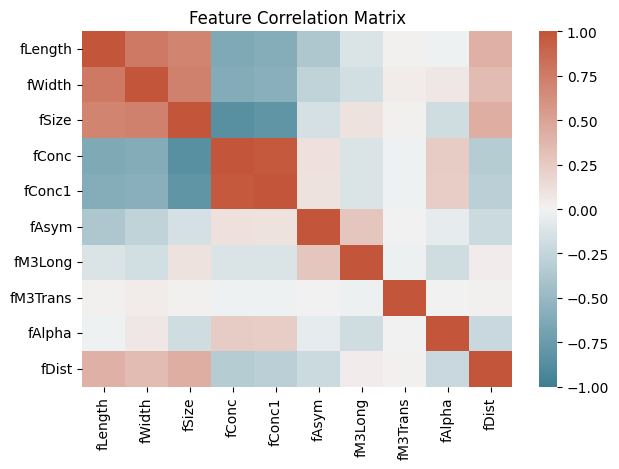

In [70]:
# ------------------------------------------------------------------------------------
# Step 1 — Correlation Matrix
# ------------------------------------------------------------------------------------
# PCA is based on variance and covariance between features. Using a *correlation* matrix
# (rather than raw covariance) puts all features on a comparable scale (unit variance),
# which is especially useful when features are measured in different units.
#
# The result is an n×n symmetric matrix (n = number of features) whose (i, j) entry
# is the correlation between feature i and feature j. The diagonal entries are all 1.
correlation_matrix = data_matrix.corr()

# Visual sanity check: pairs with high positive (≈1) or negative (≈-1) correlation
# will appear as saturated colors in this heatmap.
red_blue = sns.diverging_palette(220, 20, as_cmap=True)
sns.heatmap(correlation_matrix, vmin=-1, vmax=1, cmap=red_blue)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

<p style="font-size: 20px;"><b>Task 4</b></p>  
Use <b>NumPy’s</b> function <code>np.linalg.eig</code> to calculate the <b>eigenvectors</b> and <b>eigenvalues</b> from the correlation matrix. Then, sort the eigenvalues from greatest to smallest by first ordering their indices, and apply these indices to reorder both the eigenvalues and their corresponding eigenvectors.  

In [71]:
# ------------------------------------------------------------------------------------
# Step 2 — Eigendecomposition of the Correlation Matrix
# ------------------------------------------------------------------------------------
eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)

# ------------------------------------------------------------------------------------
# Step 3 — Inspect Results
# ------------------------------------------------------------------------------------
print("Number of features (n):", correlation_matrix.shape[0])
print("\nEigenvalues (length n):")
print(eigenvalues)

print("\nEigenvectors matrix shape:", eigenvectors.shape)
print("(Each column is one eigenvector v_k with length n.)")
print(eigenvectors)

Number of features (n): 10

Eigenvalues (length n):
[4.2239909  1.5751879  0.02024291 0.15475338 0.22036243 0.4075386
 0.74201939 0.65008647 0.9940127  1.01180532]

Eigenvectors matrix shape: (10, 10)
(Each column is one eigenvector v_k with length n.)
[[-4.08276775e-01  2.25698741e-01  1.79955894e-02 -9.04660487e-02
   7.53225050e-01 -4.37462245e-01 -1.19474438e-01 -1.49895160e-02
   2.53364917e-02 -5.00639811e-04]
 [-3.95057049e-01  2.45281583e-01 -1.17981303e-02  4.27867208e-01
  -5.39478658e-01 -4.95341859e-01 -5.78974762e-02 -1.68904043e-01
   9.46212428e-02 -1.52717635e-01]
 [-4.48921929e-01 -9.33105148e-02  1.07611883e-01 -8.15749467e-01
  -3.21598696e-01 -1.07193101e-03 -1.59226791e-02 -2.76416862e-02
   5.74952569e-02 -7.06014805e-02]
 [ 4.41612458e-01  1.88375795e-01  7.48911506e-01 -1.48746906e-01
  -7.19134376e-02 -3.30736734e-01 -1.80669622e-01 -1.04311902e-01
  -1.08617795e-01  1.28919623e-01]
 [ 4.29237789e-01  1.95951819e-01 -6.53467431e-01 -3.15173270e-01
  -1.05167458

<p style="font-size: 20px;"><b>Task 5</b></p>  
Calculate the <b>proportion of each eigenvalue</b> relative to the total sum of all eigenvalues. These proportions indicate the <b>percentage of information (variance)</b> captured by each principal component’s associated eigenvector.  

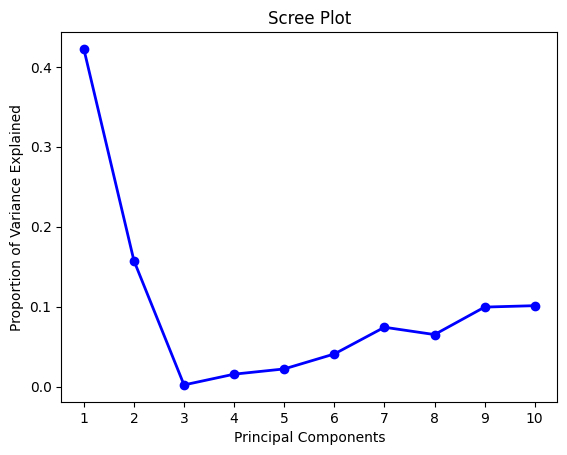

<Figure size 640x480 with 0 Axes>

In [72]:
# ------------------------------------------------------------------------------------
# Step 1 — Proportion of Information (Explained Variance per Component)
# ------------------------------------------------------------------------------------
# Each eigenvalue λ_k represents the variance explained by the corresponding 
# principal component. To compare them on the same scale, we divide each eigenvalue 
# by the sum of all eigenvalues. This gives us the proportion of total variance 
# explained by each component.
#
# info_prop[k] = λ_k / Σ λ_i
info_prop = eigenvalues / eigenvalues.sum()

# Visualize this using a scree plot:
# - X-axis: Principal component index (1...n)
# - Y-axis: Proportion of variance explained by each component
plt.plot(np.arange(1, len(info_prop) + 1), info_prop, 'bo-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Components')
plt.xticks(np.arange(1, len(info_prop) + 1))
plt.ylabel('Proportion of Variance Explained')
plt.show()
plt.clf()

<p style="font-size: 20px;"><b>Task 6</b></p>  
Compute the cumulative percentage of explained variance by summing the **ordered eigenvalues** progressively (i.e., cumulative sum of the variance proportions across principal components).  


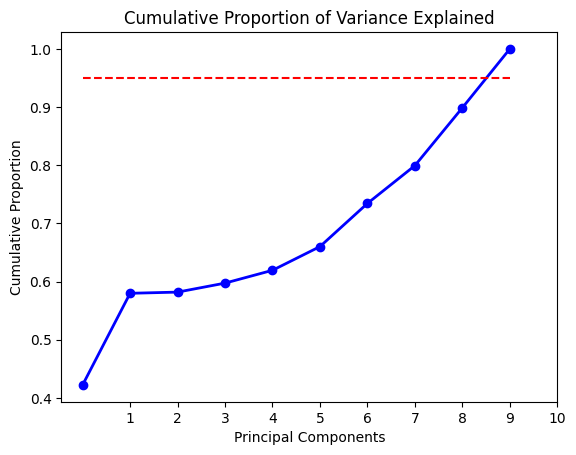

In [74]:
# ------------------------------------------------------------------------------------
# Cumulative Proportion of Information
# ------------------------------------------------------------------------------------
# To see how much information is retained by using the first k components, 
# we compute the cumulative sum of the explained variance proportions.
#
# cum_info_prop[k] = Σ (info_prop[i]) from i=1..k
cum_info_prop = np.cumsum(info_prop)

# Plot the cumulative variance explained:
# - The horizontal line at 0.95 indicates the 95% threshold.
# - The vertical line shows the smallest number of components needed to reach it.
plt.plot(cum_info_prop, 'bo-', linewidth=2)
plt.hlines(y=0.95, xmin=0, xmax=len(info_prop)-1, colors='red', linestyles='dashed')
plt.title('Cumulative Proportion of Variance Explained')
plt.xlabel('Principal Components')
plt.xticks(np.arange(1, len(info_prop) + 1))
plt.ylabel('Cumulative Proportion')
plt.show()

# Performing PCA

<p style="font-size: 20px;"><b>Task 7</b></p>  
Remember that PCA requires a <b>standardized matrix</b>, where each feature is scaled by subtracting its mean and dividing by its standard deviation. Calculate the standardized data matrix.  

In [75]:
# PCA is sensitive to scale: features with larger numeric ranges can dominate.
# Standardization makes each feature have mean = 0 and std = 1.
mean = data_matrix.mean(axis=0)
sttd = data_matrix.std(axis=0)
data_matrix_standardized = (data_matrix - mean) / sttd
print(data_matrix_standardized.head())

    fLength    fWidth     fSize     fConc    fConc1     fAsym   fM3Long  \
0 -0.577211 -0.336795 -0.381120  0.062758 -0.148919  0.541028  0.224812   
1 -0.510955 -0.570012 -0.648578  0.820362  1.471737  0.516906  0.260357   
2  2.568210  6.205695  2.615714 -1.875834 -1.773194  2.044938 -1.478497   
3 -0.694749 -0.687241 -1.029451  1.282035  1.606566  0.532757 -0.333506   
4  0.516609  0.476371  0.711138 -0.347497 -0.284652 -0.020200  0.353077   

   fM3Trans    fAlpha     fDist  
0 -0.405831  0.476803 -1.497826  
1 -0.490081 -0.815397  0.153121  
2 -2.182972  1.889174  0.842613  
3 -0.355350 -0.658786 -1.031436  
4  1.036593 -0.881016  2.176369  


<p style="font-size: 20px;"><b>Task 8</b></p>  
Use the <code>PCA</code> module from <b>scikit-learn</b> to perform Principal Component Analysis by fitting and transforming the standardized data matrix.  

In [78]:
# pca.fit() learns the eigenvectors ("principal axes") from the standardized data.
# pca.components_ has shape (n_components, n_features).
# - Each ROW corresponds to one principal component.
# - Each COLUMN corresponds to the weight of a given original feature.
pca = PCA()
principal_components = pca.fit_transform(data_matrix_standardized)
print(f'Number of features in the data matrix: {principal_components.shape[1]}')
print(f'Number of features in the principal components: {data_matrix.shape[1]}')

Number of features in the data matrix: 10
Number of features in the principal components: 10


<p style="font-size: 20px;"><b>Task 9</b></p>  
Using the trained <code>PCA</code> object <code>pca</code>, compute the <b>eigenvalues</b> from its singular values and extract the corresponding <b>eigenvectors</b>.  


In [81]:
singular_values = pca.singular_values_
print(singular_values)

[283.43620608 173.08523537 138.72103438 137.49591809 118.79590422
 111.19350036  88.03963079  64.73849703  54.25177009  19.62141655]


In [82]:
eigenvalues = singular_values ** 2
print(eigenvalues)

[80336.08291593 29958.49870176 19243.52537969 18905.12749152
 14112.46685829 12363.99452158  7750.97658907  4191.07299752
  2943.25455739   384.99998726]


In [83]:
eigenvectors = pca.components_.T
print(eigenvectors)

[[ 4.08276775e-01 -2.25698741e-01  5.00639811e-04 -2.53364917e-02
   1.19474438e-01  1.49895160e-02  4.37462245e-01  7.53225050e-01
   9.04660487e-02  1.79955894e-02]
 [ 3.95057049e-01 -2.45281583e-01  1.52717635e-01 -9.46212428e-02
   5.78974762e-02  1.68904043e-01  4.95341859e-01 -5.39478658e-01
  -4.27867208e-01 -1.17981303e-02]
 [ 4.48921929e-01  9.33105148e-02  7.06014805e-02 -5.74952569e-02
   1.59226791e-02  2.76416862e-02  1.07193101e-03 -3.21598696e-01
   8.15749467e-01  1.07611883e-01]
 [-4.41612458e-01 -1.88375795e-01 -1.28919623e-01  1.08617795e-01
   1.80669622e-01  1.04311902e-01  3.30736734e-01 -7.19134376e-02
   1.48746906e-01  7.48911506e-01]
 [-4.29237789e-01 -1.95951819e-01 -1.39197755e-01  1.16313517e-01
   2.05565490e-01  1.15773238e-01  3.89073611e-01 -1.05167458e-01
   3.15173270e-01 -6.53467431e-01]
 [-1.44687983e-01  4.86902882e-01  3.77273475e-01 -2.13916540e-01
  -2.27372884e-02  7.21816382e-01  1.13592072e-01  1.39311777e-01
   6.97106831e-03 -1.01361748e-04

<p style="font-size: 20px;"><b>Task 10</b></p>  
From the trained <code>pca</code> object, extract the <b>variance ratios</b>. These values correspond to the <b>eigenvalue proportions</b> that were calculated earlier.  

In [84]:
# Get the variance ratios from the `explained_variance_ratio_`
principal_axes_variance_ratios = pca.explained_variance_ratio_
print(principal_axes_variance_ratios)

[0.42239909 0.15751879 0.10118053 0.09940127 0.07420194 0.06500865
 0.04075386 0.02203624 0.01547534 0.00202429]


In [85]:
principal_axes_variance_percents = principal_axes_variance_ratios * 100
print(principal_axes_variance_percents )

[42.23990899 15.75187902 10.1180532   9.94012697  7.42019394  6.50086467
  4.07538598  2.20362427  1.54753381  0.20242914]


<p style="font-size: 20px;"><b>Task 11</b></p>  
Run PCA again using <b>2 principal components</b>, and be sure to <b>fit</b> and <b>transform</b> the standardized data matrix.  


In [87]:
# Calculating principal components with 2 components
# Initialize a PCA object with 2 components
pca = PCA(n_components=2) 

# Fit the standardized data and calculate the principal components
principal_components = pca.fit_transform(data_matrix_standardized)
 
# Print the DataFrame
print(f'Number of Principal Components Features: {principal_components.shape[1]}')
print(f'Number of Original Data Features: {data_matrix_standardized.shape[1]}')

Number of Principal Components Features: 2
Number of Original Data Features: 10


<p style="font-size: 20px;"><b>Task 12</b></p>  
Plot the <b>principal components</b> and set the <b>class</b> as the hue in order to visualize whether any clustering has occurred.  


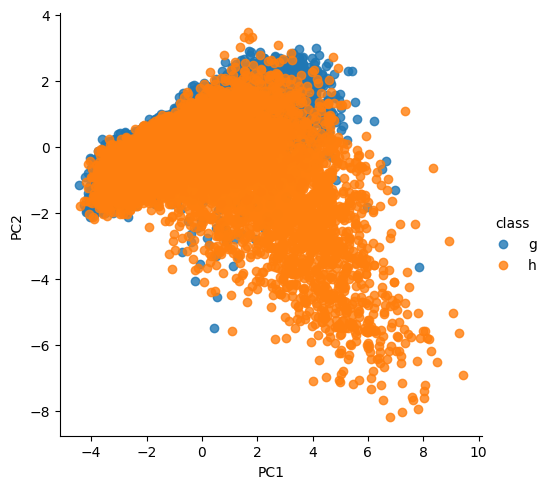

In [88]:
# Plot the principal components as a scatterplot
principal_components_data = pd.DataFrame({
    'PC1': principal_components[:, 0],
    'PC2': principal_components[:, 1],
    'class': classes,
})

sns.lmplot(x='PC1', y='PC2', data=principal_components_data, hue='class', fit_reg=False)
plt.show()

<p style="font-size: 20px;"><b>Task 13</b></p>  
Perform PCA again using <b>2 components</b>, and this time use the transformed PCA features as input to a <b>Support Vector Classifier (SVC)</b>. Fit the classifier with the transformed features and generate a performance score.  


In [91]:
# We will use the one-hot-encoded classes as the y
y = classes.astype('category').cat.codes

In [92]:
# Get principal components with 2 features 
# Perform PCA using 2 components
pca_1 = PCA(n_components=2) 
 
# Use the principal components as X and split the data into 33% testing and the rest training
X = pca_1.fit_transform(data_matrix_standardized) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
 
# Create a Linear Support Vector Classifier
svc_1 = LinearSVC(random_state=0, tol=1e-5)
svc_1.fit(X_train, y_train) 
 
# Generate a score for the testing data
score_1 = svc_1.score(X_test, y_test)
print(f'Score for model with 2 PCA features: {score_1}')

Score for model with 2 PCA features: 0.7417556157400031


<p style="font-size: 20px;"><b>Task 14</b></p>  
Fit the <b>classifier</b> using the first two features of the original <b>standardized data matrix</b> and generate a score.  

Compare the two SVC models: the first trained with the <b>PCA-transformed features</b> and the second with the <b>original features</b>. Determine which model achieves a higher accuracy score.  


In [93]:
# Using the original features 
# Select two features from the original data
first_two_original_features = [0, 1]
X_original = data_matrix_standardized.iloc[:, first_two_original_features]
 
# Split the data intro 33% testing and the rest training
X_train, X_test, y_train, y_test = train_test_split(X_original, y, test_size=0.33, random_state=42)
 
# Create a Linear Support Vector Classifier
svc_2 = LinearSVC(random_state=0)
svc_2.fit(X_train, y_train)
 
# Generate a score for the testing data
score_2 = svc_2.score(X_test, y_test)
print(f'Score for model with 2 original features: {score_2}')

Score for model with 2 original features: 0.7192926557272582


**Key Takeaway**

PCA not only helps to simplify datasets by reducing correlated features into a smaller set of principal components but can also serve as a powerful preprocessing step before classification. While dimensionality reduction often improves speed and reduces noise, it does not always guarantee higher accuracy compared to models trained on the full feature set. The key is finding the right balance between efficiency, interpretability, and predictive performance.  